# Enzyme class classification based on protein embeddings

## Context 
### Protein Embeddings (per protein) - Uniprot
https://www.uniprot.org/help/downloads#embeddings

Protein embeddings are a way to encode functional and structural properties of a protein, mostly from its sequence only, in a machine-friendly format (vector representation).
Generating such embeddings is computationally expensive, but once computed they can be leveraged for different tasks, such as sequence similarity search, sequence clustering, and sequence classification.eins).

UniProt is providing raw embeddings (per-protein and per-residue using the ProtT5 model) for UniProtKB/Swiss-Prot and some reference proteomes of model organisms (such as Homo sapiens, SARS-CoV-2, and E. coli).  
To generate embeddings, Uniprot used bio_embeddings tool, and the specific model used is prottrans_t5_xl_u50.
Note: Protein sequences longer than 12k residues are excluded due to limitation of GPU memory (this concerns only a handful of proteins).

Fetched enzyme classes from UNIPROT and merged with the embeddings for model training

## DATA

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

In [37]:
data = pd.read_csv("homo_emb.txt",sep="\t")

In [38]:
meta = pd.read_csv("meta_enzyme.txt",sep="\t")

In [39]:
data = data[data["Unnamed: 0"].isin(meta["Entry"])]

In [40]:
data.rename(columns={"Unnamed: 0": "Entry"},inplace=True)

In [45]:
data = data.merge(meta,how="inner",on="Entry")

In [51]:
data.drop(["Protein families","EC number"],axis=1,inplace=True)

In [55]:
data.set_index("Entry",inplace=True)

In [58]:
data["Enzyme class"].value_counts()

Transferases       1869
Hydrolases         1706
Oxidoreductases     562
Lyases              162
Isomerases          152
Ligases             129
Translocases        103
Name: Enzyme class, dtype: int64

In [64]:
label_encoder = LabelEncoder()
data["Enzyme class"] = label_encoder.fit_transform(data["Enzyme class"])

## PCA

Trying out dimention reduction techniques to check for any global inherant patterns

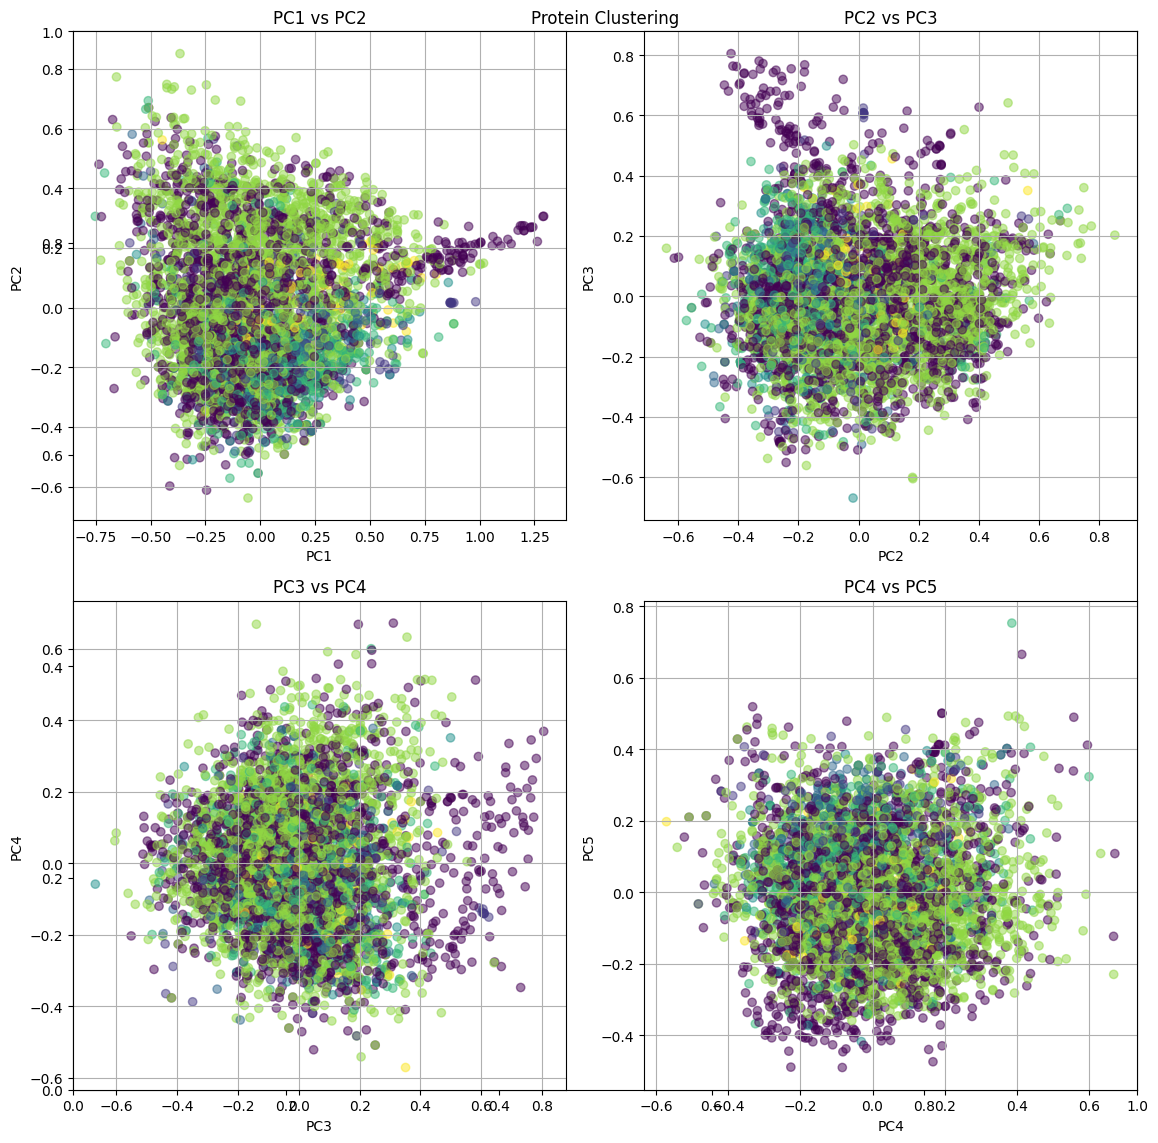

In [67]:
pca = PCA(n_components=5,random_state=42)
principal_components = pca.fit_transform(data.drop("Enzyme class",axis=1))
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2','PC3','PC4','PC5'])

pairs = [('PC1', 'PC2'), ('PC2', 'PC3'), ('PC3', 'PC4'), ('PC4', 'PC5')]

plt.figure(figsize=(12, 12))
plt.title("Protein Clustering")
for i, (x, y) in enumerate(pairs, start=1):
    plt.subplot(2, 2, i) 
    scatter = plt.scatter(
        pca_df[x], pca_df[y], cmap='viridis', alpha=0.5,c=data['Enzyme class']
    )
    
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f'{x} vs {y}')
    plt.grid(True)
plt.tight_layout()
plt.show()

## UMAP

In [68]:
import umap
import sklearn.cluster as cluster

In [70]:
standard_embedding = umap.UMAP(random_state=42,n_jobs=5).fit_transform(data.drop("Enzyme class",axis=1))

C:\Users\shasa\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


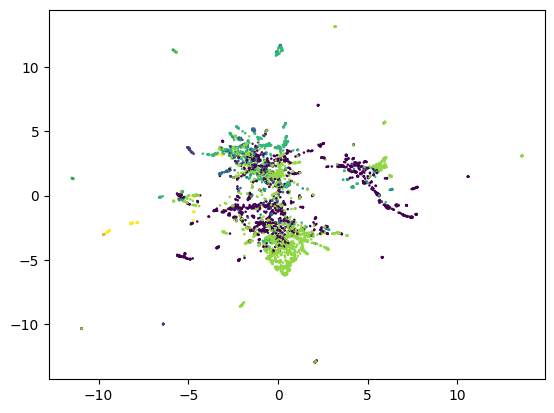

In [71]:
plt.scatter(standard_embedding[:, 0], standard_embedding[:, 1],  s=0.7, c=data['Enzyme class'], cmap='viridis'); #

No noticable pattern observed in the clusters, moving forward with NN

## NN classification model

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
#Model architecture
class ProteinClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, hidden_dim3, num_classes, dropout_rate):
        super(ProteinClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.fc3 = nn.Linear(hidden_dim2, hidden_dim3) 
        self.fc4 = nn.Linear(hidden_dim3, num_classes) 
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        
        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc3(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc4(x)
        return x

#creating a dataloader object
class ProteinDataset(Dataset):
    def __init__(self, df, label_column):
        self.embeddings = torch.tensor(df.drop(columns=[label_column]).values, dtype=torch.float32)
        self.labels = torch.tensor(df[label_column].values, dtype=torch.long)

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]

In [74]:
def train_model(model, data_loader, epochs):
    model.train()
    for epoch in range(epochs):
        for batch in data_loader:
            inputs, labels = batch
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

In [75]:
def evaluate_model(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in data_loader:
            inputs, labels = batch
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            # Get predictions
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    accuracy = accuracy_score(all_labels, all_preds) * 100
    avg_loss = total_loss / len(data_loader)
    print(f"Test Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.2f}%")


    cm = confusion_matrix(all_labels, all_preds)
    print("Confusion Matrix:\n", cm)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(all_labels), yticklabels=np.unique(all_labels))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

In [77]:
input_dim = 1024
hidden_dim1 = 512
hidden_dim2 = 259
hidden_dim3 = 128
num_classes = 7
dropout_rate = 0.5

model = ProteinClassifier(input_dim, hidden_dim1, hidden_dim2, hidden_dim3, num_classes, dropout_rate)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

label_column = "Enzyme class"
train_df, test_df = train_test_split(data, test_size=0.2, stratify=data[label_column], random_state=42)

train_dataset = ProteinDataset(train_df, label_column)
test_dataset = ProteinDataset(test_df, label_column)

train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)

In [80]:
train_model(model, train_loader,epochs=100)

Epoch [1/100], Loss: 0.2306
Epoch [2/100], Loss: 0.1712
Epoch [3/100], Loss: 0.2938
Epoch [4/100], Loss: 0.2701
Epoch [5/100], Loss: 0.1058
Epoch [6/100], Loss: 0.1034
Epoch [7/100], Loss: 0.2020
Epoch [8/100], Loss: 0.2538
Epoch [9/100], Loss: 0.0938
Epoch [10/100], Loss: 0.2184
Epoch [11/100], Loss: 0.0769
Epoch [12/100], Loss: 0.1343
Epoch [13/100], Loss: 0.0144
Epoch [14/100], Loss: 0.1041
Epoch [15/100], Loss: 0.0824
Epoch [16/100], Loss: 0.1752
Epoch [17/100], Loss: 0.0195
Epoch [18/100], Loss: 0.0815
Epoch [19/100], Loss: 0.2378
Epoch [20/100], Loss: 0.0346
Epoch [21/100], Loss: 0.1289
Epoch [22/100], Loss: 0.3555
Epoch [23/100], Loss: 0.0342
Epoch [24/100], Loss: 0.0684
Epoch [25/100], Loss: 0.2045
Epoch [26/100], Loss: 0.0859
Epoch [27/100], Loss: 0.0621
Epoch [28/100], Loss: 0.0516
Epoch [29/100], Loss: 0.2083
Epoch [30/100], Loss: 0.2011
Epoch [31/100], Loss: 0.1313
Epoch [32/100], Loss: 0.1264
Epoch [33/100], Loss: 0.0088
Epoch [34/100], Loss: 0.1332
Epoch [35/100], Loss: 0

Test Loss: 1.0280, Test Accuracy: 84.53%
Confusion Matrix:
 [[305   0   0   7   4  25   0]
 [  5  16   0   3   5   1   0]
 [  1   0  19   0   1   5   0]
 [  2   2   1  15   4   8   0]
 [  9   2   0   5  90   7   0]
 [ 29   2   1   4  11 327   0]
 [  0   0   0   0   1   0  20]]


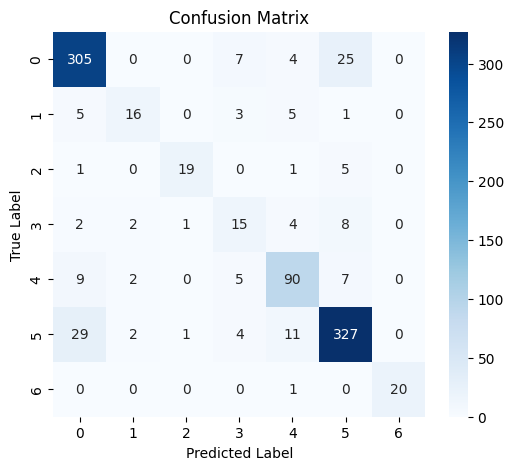

In [81]:
evaluate_model(model, test_loader)

The class imblance might be causing drop in performance due to dominant classes, hence over sampling to handle class imbalance

In [83]:
from imblearn.over_sampling import RandomOverSampler

In [87]:
ros = RandomOverSampler(random_state=42)
over_data, y = ros.fit_resample(data.drop("Enzyme class",axis=1), data["Enzyme class"])

In [88]:
over_data["Enzyme class"] = y

C:\Users\shasa\AppData\Local\Temp\ipykernel_9948\889094149.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  over_data["Enzyme class"] = y


In [90]:
label_column = "Enzyme class"
train_df, test_df = train_test_split(over_data, test_size=0.2, stratify=over_data[label_column], random_state=42)

train_dataset = ProteinDataset(train_df, label_column)
test_dataset = ProteinDataset(test_df, label_column)

train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)

In [91]:
train_model(model, train_loader,epochs=100)

Epoch [1/100], Loss: 0.1827
Epoch [2/100], Loss: 0.3043
Epoch [3/100], Loss: 0.0693
Epoch [4/100], Loss: 0.1758
Epoch [5/100], Loss: 0.0479
Epoch [6/100], Loss: 0.1144
Epoch [7/100], Loss: 0.1845
Epoch [8/100], Loss: 0.1395
Epoch [9/100], Loss: 0.1203
Epoch [10/100], Loss: 0.0523
Epoch [11/100], Loss: 0.1167
Epoch [12/100], Loss: 0.0880
Epoch [13/100], Loss: 0.1427
Epoch [14/100], Loss: 0.0263
Epoch [15/100], Loss: 0.0840
Epoch [16/100], Loss: 0.1238
Epoch [17/100], Loss: 0.0681
Epoch [18/100], Loss: 0.1617
Epoch [19/100], Loss: 0.0609
Epoch [20/100], Loss: 0.1092
Epoch [21/100], Loss: 0.0410
Epoch [22/100], Loss: 0.0771
Epoch [23/100], Loss: 0.0970
Epoch [24/100], Loss: 0.0368
Epoch [25/100], Loss: 0.1119
Epoch [26/100], Loss: 0.2209
Epoch [27/100], Loss: 0.0799
Epoch [28/100], Loss: 0.1323
Epoch [29/100], Loss: 0.1001
Epoch [30/100], Loss: 0.0426
Epoch [31/100], Loss: 0.0896
Epoch [32/100], Loss: 0.0436
Epoch [33/100], Loss: 0.0956
Epoch [34/100], Loss: 0.0723
Epoch [35/100], Loss: 0

Test Loss: 0.1342, Test Accuracy: 96.75%
Confusion Matrix:
 [[344   2   1  12   3  11   0]
 [  0 363   0  11   0   0   0]
 [  0   0 374   0   0   0   0]
 [  0  15   3 356   0   0   0]
 [  2   2   0   3 367   0   0]
 [ 11   3   0   4   2 354   0]
 [  0   0   0   0   0   0 374]]


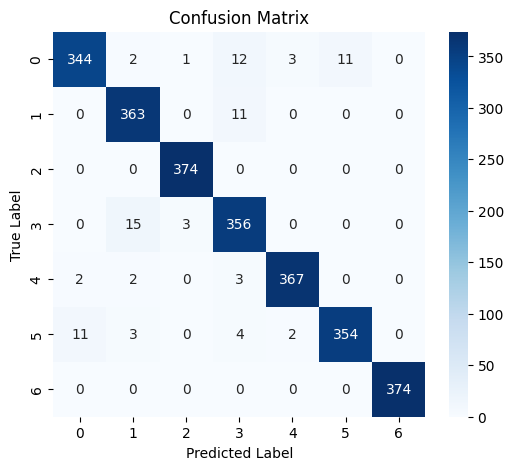

In [92]:
evaluate_model(model, test_loader) #12% improvement